# Year-over-year сезонность: февраль–март

Финальный прогноз строится на период `2026-02-14 — 2026-03-15`. Он включает 14 февраля, подготовку к 23 февраля и 8 марта, а также сами праздничные периоды. Текущий набор `enhanced_v2` ограничен 180 днями и не видит февраль–март 2025 года.

Задача ноутбука — проверить, содержит ли тот же календарный период прошлого года дополнительный пользовательский сигнал. Основная модель не переобучается: сначала оцениваются прямые прошлогодние прогнозы и их blend с честным CatBoost OOF на зимнем holdout `2026-01-14`.

## 0. Режим запуска

При `REBUILD_FEATURES=True` сезонные признаки пересчитываются из исходного parquet. После завершения эксперимента флаг выключается, и повторный запуск загружает готовые артефакты.

In [1]:
REBUILD_FEATURES = False

VALIDATION_ANCHOR = '2026-01-14'
FINAL_ANCHOR = '2026-02-13'
N_USER_FOLDS = 5

## 1. Импорты и исходные данные

In [2]:
from __future__ import annotations

from datetime import date
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

project_root = Path.cwd().resolve()
if not (project_root / 'src').is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    CATBOOST_SEASONALITY_DIR,
    CATBOOST_TUNING_DIR,
    ensure_output_dirs,
)
from src.data import all_users, load_train, summarize_data
from src.seasonality import (
    build_year_over_year_features,
    daily_market_series,
    seasonal_window_dates,
)
from src.validation import rmsle

ensure_output_dirs()
data = load_train()
users = all_users(data)
summary = summarize_data(data)
display(pd.DataFrame([summary]))

,rows,users,min_date,max_date,days,positive_gmv_row_share,max_gmv_identity_error,max_order_identity_error
0,30631006,250000,2025-01-01,2026-02-13,409,0.154644,5.275069e-11,0


## 2. Какие даты используются

Для каждого якоря строятся:

- прошлогодний календарный аналог будущих 30 дней;
- аналог со сдвигом на 364 дня, сохраняющий день недели;
- текущие 14 дней перед якорем;
- те же 14 календарных дней год назад;
- четыре последовательных сегмента прошлогоднего горизонта длиной 7, 8, 8 и 7 дней.

In [3]:
validation_anchor = date.fromisoformat(VALIDATION_ANCHOR)
final_anchor = date.fromisoformat(FINAL_ANCHOR)

for name, anchor in [('validation', validation_anchor), ('final', final_anchor)]:
    print(f'\n{name}: anchor={anchor}, forecast={anchor.fromordinal(anchor.toordinal()+1)} — {anchor.fromordinal(anchor.toordinal()+30)}')
    for window_name, bounds in seasonal_window_dates(anchor).items():
        print(f'  {window_name:24s}: {bounds[0]} — {bounds[1]}')


validation: anchor=2026-01-14, forecast=2026-01-15 — 2026-02-13
  current_pre_14d         : 2026-01-01 — 2026-01-14
  ly_pre_14d              : 2025-01-01 — 2025-01-14
  ly_calendar_horizon     : 2025-01-15 — 2025-02-13
  ly_weekday_horizon      : 2025-01-16 — 2025-02-14
  ly_segment_1            : 2025-01-15 — 2025-01-21
  ly_segment_2            : 2025-01-22 — 2025-01-29
  ly_segment_3            : 2025-01-30 — 2025-02-06
  ly_segment_4            : 2025-02-07 — 2025-02-13

final: anchor=2026-02-13, forecast=2026-02-14 — 2026-03-15
  current_pre_14d         : 2026-01-31 — 2026-02-13
  ly_pre_14d              : 2025-01-31 — 2025-02-13
  ly_calendar_horizon     : 2025-02-14 — 2025-03-15
  ly_weekday_horizon      : 2025-02-15 — 2025-03-16
  ly_segment_1            : 2025-02-14 — 2025-02-20
  ly_segment_2            : 2025-02-21 — 2025-02-28
  ly_segment_3            : 2025-03-01 — 2025-03-08
  ly_segment_4            : 2025-03-09 — 2025-03-15


## 3. Дневная динамика начала 2025 года

График — диагностика, а не доказательство причинного эффекта праздников. Он показывает, менялись ли глобальные GMV, заказы и поиски внутри доступного прошлогоднего аналога.

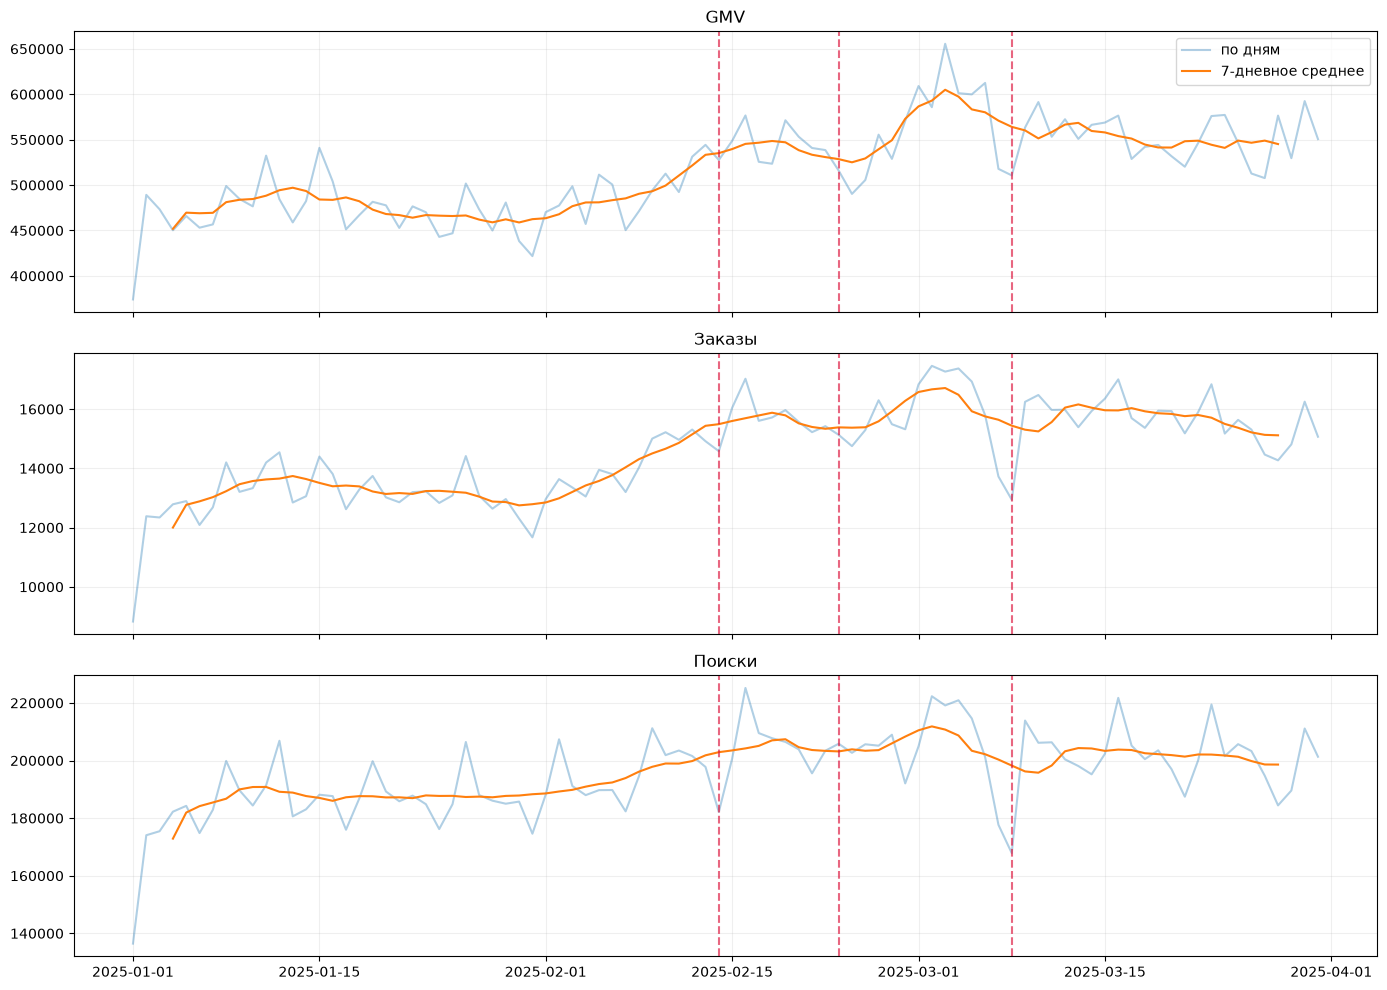

In [4]:
daily_path = CATBOOST_SEASONALITY_DIR / 'daily_market_2025_q1.parquet'
if REBUILD_FEATURES or not daily_path.exists():
    daily = daily_market_series(data, date(2025, 1, 1), date(2025, 3, 31))
    daily.write_parquet(daily_path)
else:
    daily = pl.read_parquet(daily_path)
daily_pd = daily.to_pandas().set_index('event_date')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for axis, column, title in zip(
    axes,
    ['gmv', 'orders', 'searches'],
    ['GMV', 'Заказы', 'Поиски'],
):
    axis.plot(daily_pd.index, daily_pd[column], alpha=0.35, label='по дням')
    axis.plot(daily_pd.index, daily_pd[column].rolling(7, center=True).mean(), label='7-дневное среднее')
    for holiday, label in [(pd.Timestamp('2025-02-14'), '14 февраля'), (pd.Timestamp('2025-02-23'), '23 февраля'), (pd.Timestamp('2025-03-08'), '8 марта')]:
        axis.axvline(holiday, color='crimson', linestyle='--', alpha=0.65)
    axis.set_title(title)
    axis.grid(alpha=0.2)
axes[0].legend()
plt.tight_layout()
plt.show()

## 4. Построение сезонных пользовательских признаков

Валидационный срез нужен для измерения качества. Финальный срез строится сейчас, чтобы после принятия решения не перечитывать исходные 30 миллионов строк.

In [5]:
seasonal_paths = {
    validation_anchor: CATBOOST_SEASONALITY_DIR / f'features_{validation_anchor}.parquet',
    final_anchor: CATBOOST_SEASONALITY_DIR / f'features_{final_anchor}.parquet',
}
seasonal_features = {}
seasonal_windows = {}
for anchor, path in seasonal_paths.items():
    if REBUILD_FEATURES or not path.exists():
        print(f'Строим year-over-year признаки для {anchor} ...')
        feature_frame, windows = build_year_over_year_features(data, users, anchor)
        feature_frame.write_parquet(path, compression='zstd')
    else:
        feature_frame = pl.read_parquet(path)
        windows = seasonal_window_dates(anchor)
        print(f'Загружено: {path.name}')
    seasonal_features[anchor] = feature_frame
    seasonal_windows[anchor] = windows
    print(f'  rows={feature_frame.height:,}; columns={feature_frame.width}')

Загружено: features_2026-01-14.parquet
  rows=250,000; columns=61


Загружено: features_2026-02-13.parquet
  rows=250,000; columns=61


## 5. Формирование зимнего holdout

CatBoost-предсказание для `2026-01-14` является честным временным OOF: модель обучалась только на более ранних якорях, цели которых закончились до этой даты. К нему присоединяются прошлогодние признаки по `user_id`.

In [6]:
depth6_oof = pd.read_parquet(CATBOOST_TUNING_DIR / 'depth_winner_oof.parquet')
depth6_oof['validation_anchor'] = pd.to_datetime(depth6_oof['validation_anchor']).dt.date
winter_oof = depth6_oof[
    depth6_oof['validation_anchor'] == validation_anchor
].copy()
winter = winter_oof.merge(
    seasonal_features[validation_anchor].drop('anchor_date').to_pandas(),
    on='user_id',
    how='left',
    validate='one_to_one',
)
assert len(winter) == 250_000
assert winter['target'].notna().all()
print(f'CatBoost RMSLE на зимнем holdout: {rmsle(winter.target.to_numpy(), winter.prediction.to_numpy()):.6f}')
print(f'Пользователей с GMV в прошлогоднем горизонте: {winter.has_ly_horizon_gmv.mean():.2%}')

CatBoost RMSLE на зимнем holdout: 1.703598
Пользователей с GMV в прошлогоднем горизонте: 36.73%


## 6. Прямые прошлогодние прогнозы

Сравниваются календарный аналог, 364-дневный аналог, их масштабированные версии и среднее двух масштабированных прогнозов. Эти методы не обучаются на target 2026 года.

In [7]:
SEASONAL_CANDIDATES = {
    'ly_calendar': 'ly_calendar_horizon_gmv',
    'ly_weekday': 'ly_weekday_horizon_gmv',
    'scaled_ly_calendar': 'scaled_ly_calendar_gmv',
    'scaled_ly_weekday': 'scaled_ly_weekday_gmv',
}
winter['scaled_ly_mean_gmv'] = 0.5 * (
    winter['scaled_ly_calendar_gmv'] + winter['scaled_ly_weekday_gmv']
)
SEASONAL_CANDIDATES['scaled_ly_mean'] = 'scaled_ly_mean_gmv'

direct_rows = [{
    'method': 'catboost_depth6',
    'rmsle': rmsle(winter.target.to_numpy(), winter.prediction.to_numpy()),
}]
for method, column in SEASONAL_CANDIDATES.items():
    direct_rows.append({
        'method': method,
        'rmsle': rmsle(winter.target.to_numpy(), winter[column].to_numpy()),
    })
direct_metrics = pd.DataFrame(direct_rows).sort_values('rmsle')
direct_metrics.to_csv(CATBOOST_SEASONALITY_DIR / 'direct_metrics.csv', index=False)
display(direct_metrics)

,method,rmsle
0,catboost_depth6,1.703598
5,scaled_ly_mean,2.509884
2,ly_weekday,2.512156
1,ly_calendar,2.512997
4,scaled_ly_weekday,2.518560
3,scaled_ly_calendar,2.519110


## 7. Сегментный анализ

Прямой прошлогодний прогноз ожидаемо неприменим к части пользователей. Поэтому качество проверяется отдельно для пользователей с покупками год назад, новых относительно прошлого года и ушедших из текущей активности.

In [8]:
segments = {
    'all': np.ones(len(winter), dtype=bool),
    'has_ly_horizon_gmv': winter['has_ly_horizon_gmv'].to_numpy() == 1,
    'no_ly_horizon_gmv': winter['has_ly_horizon_gmv'].to_numpy() == 0,
    'active_now': winter['has_current_pre_gmv'].to_numpy() == 1,
    'new_vs_last_year': winter['is_new_vs_last_year'].to_numpy() == 1,
    'lapsed_vs_last_year': winter['is_lapsed_vs_last_year'].to_numpy() == 1,
}
segment_rows = []
for segment_name, mask in segments.items():
    if mask.sum() == 0:
        continue
    segment_rows.append({
        'segment': segment_name,
        'users': int(mask.sum()),
        'share': float(mask.mean()),
        'catboost_rmsle': rmsle(winter.loc[mask, 'target'].to_numpy(), winter.loc[mask, 'prediction'].to_numpy()),
        'scaled_ly_calendar_rmsle': rmsle(winter.loc[mask, 'target'].to_numpy(), winter.loc[mask, 'scaled_ly_calendar_gmv'].to_numpy()),
    })
segment_metrics = pd.DataFrame(segment_rows)
segment_metrics.to_csv(CATBOOST_SEASONALITY_DIR / 'segment_metrics.csv', index=False)
display(segment_metrics)

ly_positive = winter['ly_calendar_horizon_gmv'].to_numpy() > 0
target_positive = winter['target'].to_numpy() > 0
log_yoy_correlation = float(np.corrcoef(
    np.log1p(winter['target'].to_numpy()),
    np.log1p(winter['ly_calendar_horizon_gmv'].to_numpy()),
)[0, 1])
target_positive_if_ly_positive = float(target_positive[ly_positive].mean())
target_positive_if_ly_zero = float(target_positive[~ly_positive].mean())
print(f'Корреляция log1p текущего и прошлогоднего GMV: {log_yoy_correlation:.3f}')
print(f'P(target>0 | прошлогодний GMV>0): {target_positive_if_ly_positive:.2%}')
print(f'P(target>0 | прошлогодний GMV=0): {target_positive_if_ly_zero:.2%}')

,segment,users,share,catboost_rmsle,scaled_ly_calendar_rmsle
0,all,250000,1.000000,1.703598,2.519110
1,has_ly_horizon_gmv,91819,0.367276,1.726451,2.381769
2,no_ly_horizon_gmv,158181,0.632724,1.690190,2.595501
3,active_now,93603,0.374412,1.718208,2.877081
4,new_vs_last_year,35150,0.140600,1.883932,3.544292
5,lapsed_vs_last_year,48273,0.193092,1.899865,2.709463


Корреляция log1p текущего и прошлогоднего GMV: 0.414
P(target>0 | прошлогодний GMV>0): 76.11%
P(target>0 | прошлогодний GMV=0): 41.27%


## 8. Cross-user OOF blend с CatBoost

Сезонный прогноз смешивается с CatBoost в пространстве `log1p`. Он применяется только к пользователям с ненулевым прошлогодним GMV; для остальных прогноз CatBoost не меняется.

Чтобы не подбирать вес и оценивать его на тех же пользователях, используется пять детерминированных групп `user_id % 5`. Для каждой контрольной группы метод и вес выбираются на остальных четырёх группах.

In [9]:
def gated_log_blend(base, seasonal, weight):
    base = np.asarray(base, dtype=float)
    seasonal = np.asarray(seasonal, dtype=float)
    result = base.copy()
    gate = seasonal > 0
    result[gate] = np.expm1(
        (1.0 - weight) * np.log1p(np.clip(base[gate], 0, None))
        + weight * np.log1p(np.clip(seasonal[gate], 0, None))
    )
    return np.clip(result, 0, None)

weights = np.round(np.arange(0.0, 0.61, 0.025), 3)
user_folds = (winter['user_id'].to_numpy() % N_USER_FOLDS).astype(int)
blend_oof = np.zeros(len(winter), dtype=float)
choice_rows = []

for fold in range(N_USER_FOLDS):
    train_mask = user_folds != fold
    valid_mask = ~train_mask
    best = None
    for method, column in SEASONAL_CANDIDATES.items():
        for weight in weights:
            train_prediction = gated_log_blend(
                winter.loc[train_mask, 'prediction'].to_numpy(),
                winter.loc[train_mask, column].to_numpy(),
                weight,
            )
            score = rmsle(winter.loc[train_mask, 'target'].to_numpy(), train_prediction)
            if best is None or score < best['train_rmsle']:
                best = {'method': method, 'column': column, 'weight': float(weight), 'train_rmsle': score}
    fold_prediction = gated_log_blend(
        winter.loc[valid_mask, 'prediction'].to_numpy(),
        winter.loc[valid_mask, best['column']].to_numpy(),
        best['weight'],
    )
    blend_oof[valid_mask] = fold_prediction
    best['fold'] = fold
    best['valid_rmsle'] = rmsle(winter.loc[valid_mask, 'target'].to_numpy(), fold_prediction)
    choice_rows.append(best)

blend_choices = pd.DataFrame(choice_rows).sort_values('fold')
blend_choices.to_csv(CATBOOST_SEASONALITY_DIR / 'blend_fold_choices.csv', index=False)
display(blend_choices)
base_score = rmsle(winter.target.to_numpy(), winter.prediction.to_numpy())
blend_score = rmsle(winter.target.to_numpy(), blend_oof)
print(f'CatBoost winter RMSLE:       {base_score:.6f}')
print(f'Cross-user blend RMSLE:      {blend_score:.6f}')
print(f'Улучшение:                   {base_score - blend_score:+.6f}')

,method,column,weight,train_rmsle,fold,valid_rmsle
0,ly_calendar,ly_calendar_horizon_gmv,0.025,1.703383,0,1.703002
1,ly_calendar,ly_calendar_horizon_gmv,0.025,1.703097,1,1.704141
2,ly_calendar,ly_calendar_horizon_gmv,0.025,1.702810,2,1.705304
3,ly_calendar,ly_calendar_horizon_gmv,0.025,1.704600,3,1.698108
4,ly_calendar,ly_calendar_horizon_gmv,0.025,1.702638,4,1.705962


CatBoost winter RMSLE:       1.703598
Cross-user blend RMSLE:      1.703306
Улучшение:                   +0.000292


## 9. Сохранение результата и характеристик финального среза

In [10]:
blend_output = winter[['user_id', 'target', 'prediction']].copy()
blend_output['seasonal_blend_prediction'] = blend_oof
blend_output['user_fold'] = user_folds
blend_output.to_parquet(CATBOOST_SEASONALITY_DIR / 'seasonal_blend_oof.parquet', index=False)

final_seasonal = seasonal_features[final_anchor]
final_coverage = final_seasonal.select(
    pl.col('has_ly_horizon_gmv').mean().alias('has_ly_horizon_gmv_share'),
    pl.col('has_current_pre_gmv').mean().alias('has_current_pre_gmv_share'),
    pl.col('is_new_vs_last_year').mean().alias('new_vs_last_year_share'),
    pl.col('is_lapsed_vs_last_year').mean().alias('lapsed_vs_last_year_share'),
).to_dicts()[0]

recommended_method = blend_choices['method'].mode().iloc[0]
recommended_weight = float(blend_choices.loc[blend_choices.method == recommended_method, 'weight'].median())
result_summary = {
    'validation_anchor': VALIDATION_ANCHOR,
    'final_anchor': FINAL_ANCHOR,
    'catboost_winter_rmsle': float(base_score),
    'cross_user_blend_rmsle': float(blend_score),
    'improvement': float(base_score - blend_score),
    'recommended_method': recommended_method,
    'recommended_weight': recommended_weight,
    'log_yoy_correlation': log_yoy_correlation,
    'target_positive_if_ly_positive': target_positive_if_ly_positive,
    'target_positive_if_ly_zero': target_positive_if_ly_zero,
    'final_coverage': final_coverage,
    'validation_limitation': 'one winter anchor; cross-user OOF is not multi-year temporal validation',
}
with open(CATBOOST_SEASONALITY_DIR / 'summary.json', 'w', encoding='utf-8') as file:
    json.dump(result_summary, file, ensure_ascii=False, indent=2)
display(pd.DataFrame([result_summary]))

,validation_anchor,final_anchor,catboost_winter_rmsle,cross_user_blend_rmsle,improvement,recommended_method,recommended_weight,log_yoy_correlation,target_positive_if_ly_positive,target_positive_if_ly_zero,final_coverage,validation_limitation
0,2026-01-14,2026-02-13,1.703598,1.703306,0.000292,ly_calendar,0.025,0.41383,0.761106,0.412698,"{'has_ly_horizon_gmv_share': 0.402928, 'has_cu...",one winter anchor; cross-user OOF is not multi...


## 10. Ограничение эксперимента

Это не обычная четырёхфолдовая временная валидация: данные начинаются в январе 2025 года, поэтому полноценный прошлогодний аналог существует только для зимнего якоря `2026-01-14` и финального среза. Cross-user OOF защищает от подбора веса на тех же пользователях, но не доказывает переносимость между разными годами и праздничными календарями.

## Итог

Глобальная динамика 2025 года подтверждает, что период, соответствующий финальному горизонту, отличается от предыдущих 30 дней. Среднедневной GMV относительно `15 января — 13 февраля` был выше примерно на 14% в `14–20 февраля`, на 11% в `21–28 февраля`, на 22% в `1–8 марта` и на 18% в `9–15 марта`. Это не доказывает причинный эффект праздников, поскольку одновременно присутствуют тренд рынка и недельная сезонность, но игнорировать период нельзя.

Прямой перенос прошлогодней суммы не работает: лучшие year-over-year baseline имеют RMSLE около `2.51`, тогда как CatBoost получает `1.703598`. Простое масштабирование по последним 14 дням не помогло и немного ухудшило прямой прогноз. Денежный масштаб пользователя заметно меняется между годами.

При этом прошлогодняя активность содержит полезный классификационный сигнал. Корреляция `log1p` текущего и прошлогоднего GMV равна `0.414`. Среди пользователей с GMV в аналогичном горизонте прошлого года 76.1% имеют ненулевой target; среди остальных — 41.3%. Значит, прошлогодний период перспективнее использовать как признак вероятности и устойчивости активности, а не как замену прогноза CatBoost.

В пяти cross-user фолдах независимо выбраны один и тот же календарный аналог и одинаковый вес `0.025`. Gated log-blend снизил RMSLE с `1.703598` до `1.703306`, улучшение равно `0.000292`. Стабильность выбора говорит, что слабый дополнительный сигнал воспроизводится между группами пользователей, но его величина мала.

В финальном срезе прошлогодний GMV присутствует у 40.3% пользователей; 13.3% определены как новые относительно прошлого года, 20.2% — как ушедшие из текущей активности. Поэтому year-over-year признаки нельзя применять одинаково ко всей выборке.

Решение: сезонные признаки сохраняются для следующей модели, но прошлогодний GMV не используется как самостоятельный прогноз и пока не становится основанием для нового submission. Следующий эксперимент должен проверить `has_ly_horizon_gmv`, сегменты горизонта, число активных дней, канальные доли и YoY-масштаб как входы модели или отдельной модели коррекции. Все данные для такого эксперимента уже сохранены.